# Diffuse sky versus point-source angular power

This notebook overplots the angular power spectrum of the complete source-free sky (`no_sources`) and the coherent sum of the analytic A-team point sources (`ateam`). It reads the canonical, un-beamed harmonic product directly, so no map synthesis, display beam, or HEALPix pixel-window correction enters the comparison.

The diffuse realization is resolution-validated through $\ell=64$; the hatched region is retained in the product but should not be interpreted as converged diffuse small-scale structure.

In [1]:
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

Set `PRODUCT` explicitly when using a different generated realization. The fallback search works when the notebook is launched from either the repository root or `notebooks/`.

In [2]:
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent

candidates = [
    root / "outputs_our_sky_gum_gaussian_final" / "counterfactual_ulsa_harmonic.npz",
    root / "outputs_our_sky_harmonic" / "counterfactual_ulsa_harmonic.npz",
    root / "lowsky-output" / "counterfactual_ulsa_harmonic.npz",
]
PRODUCT = next((path for path in candidates if path.exists()), candidates[0])
if not PRODUCT.exists():
    raise FileNotFoundError(
        f"No harmonic product found at {PRODUCT}. Run lowsky-generate first, "
        "or set PRODUCT to counterfactual_ulsa_harmonic.npz."
    )
PRODUCT.relative_to(root)

PosixPath('outputs_our_sky_gum_gaussian_final/counterfactual_ulsa_harmonic.npz')

In [3]:
with np.load(PRODUCT, allow_pickle=False) as product:
    frequencies_mhz = np.asarray(product["frequency_mhz"], dtype=float)
    diffuse_alms = np.asarray(product["no_sources"])
    point_source_alms = np.asarray(product["ateam"])
    lmax = int(product["lmax"])
    input_nside = int(product["input_nside"])

expected_shape = (frequencies_mhz.size, hp.Alm.getsize(lmax))
assert diffuse_alms.shape == expected_shape
assert point_source_alms.shape == expected_shape

diffuse_cl = np.stack([hp.alm2cl(alm) for alm in diffuse_alms])
point_source_cl = np.stack([hp.alm2cl(alm) for alm in point_source_alms])
ell = np.arange(lmax + 1)
print(f"{frequencies_mhz.size} frequencies, lmax={lmax}, input NSIDE={input_nside}")

50 frequencies, lmax=191, input NSIDE=64


The point-source curve is not perfectly flat because it is the power of the **coherent summed sky**: cross terms between sources oscillate with $\ell$. A sum of the individual source powers would instead give the usual flat, incoherent shot-noise level.

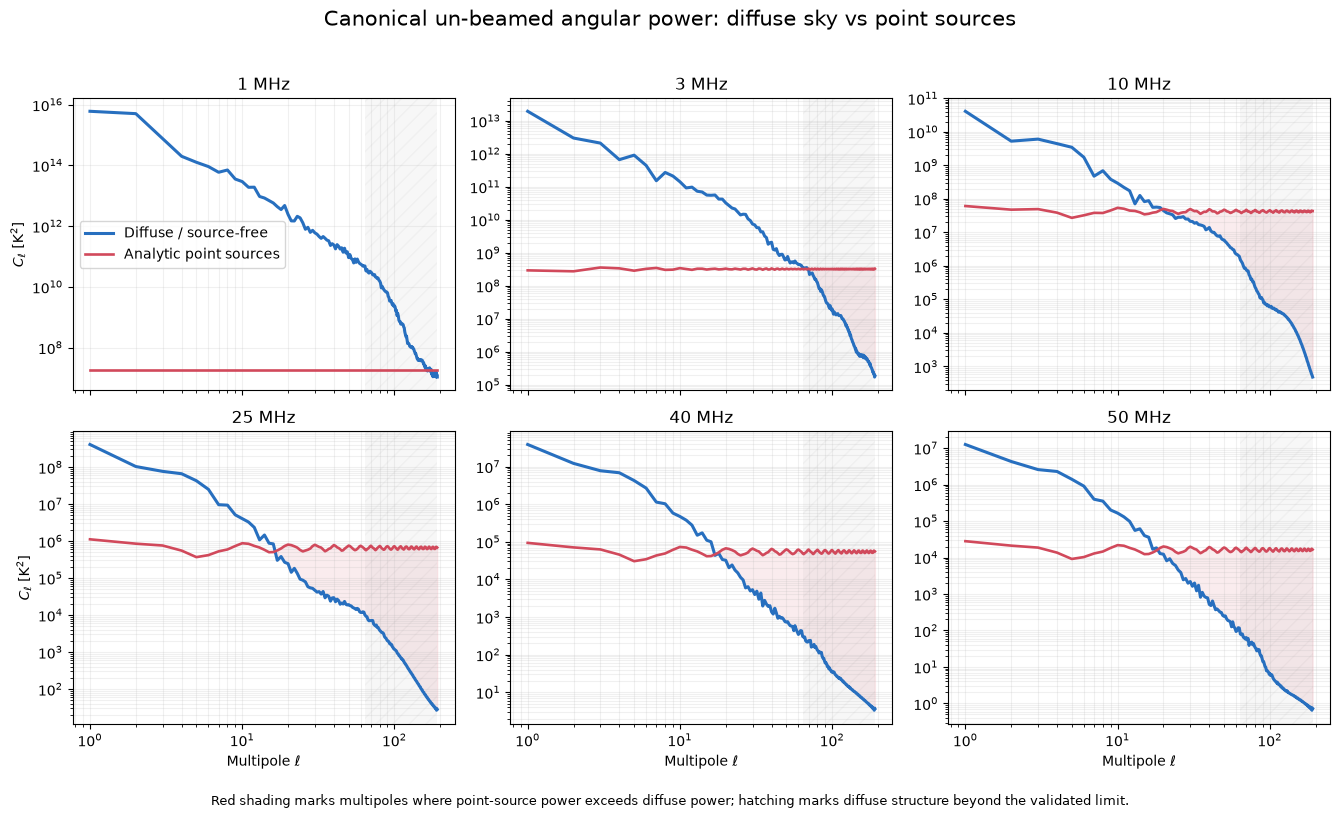

In [4]:
requested_frequencies_mhz = np.array([1.0, 3.0, 10.0, 25.0, 40.0, 50.0])
frequency_indices = [np.argmin(np.abs(frequencies_mhz - value)) for value in requested_frequencies_mhz]
valid = ell >= 1
validated_ell_max = input_nside  # NSIDE=64 versus NSIDE=128 convergence audit

fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.2), sharex=True)
for ax, fi in zip(axes.flat, frequency_indices):
    ax.loglog(
        ell[valid], diffuse_cl[fi, valid],
        color="#276FBF", lw=2.2, label="Diffuse / source-free",
    )
    ax.loglog(
        ell[valid], point_source_cl[fi, valid],
        color="#D1495B", lw=1.9, label="Analytic point sources",
    )
    ax.fill_between(
        ell[valid], diffuse_cl[fi, valid], point_source_cl[fi, valid],
        where=point_source_cl[fi, valid] >= diffuse_cl[fi, valid],
        color="#D1495B", alpha=0.10,
    )
    if validated_ell_max < lmax:
        ax.axvspan(validated_ell_max, lmax, color="0.2", alpha=0.035, hatch="//", lw=0)
    ax.set_title(f"{frequencies_mhz[fi]:g} MHz")
    ax.grid(which="both", alpha=0.18)

for ax in axes[:, 0]:
    ax.set_ylabel(r"$C_\ell$ [K$^2$]")
for ax in axes[-1, :]:
    ax.set_xlabel(r"Multipole $\ell$")
axes.flat[0].legend(loc="best")
fig.suptitle("Canonical un-beamed angular power: diffuse sky vs point sources", fontsize=15)
fig.text(
    0.5, 0.01,
    "Red shading marks multipoles where point-source power exceeds diffuse power; "
    "hatching marks diffuse structure beyond the validated limit.",
    ha="center", fontsize=9,
)
fig.tight_layout(rect=(0, 0.035, 1, 0.96));